# Part A: Sentiment Analysis with RNN/LSTM

## Step 1: Data Preparation

In [1]:
import os
import tarfile
import urllib.request

# --- Step 1: Download & Extract ---
url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

# Check if folder exists
if not os.path.exists("aclImdb"):
    if not os.path.exists(filename):
        print("Downloading IMDB dataset ... this might take a minute.")
        urllib.request.urlretrieve(url, filename)
        print("Download complete.")
    
    print("Extracting files... (this takes a moment)")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete.")
else:
    print("IMDB dataset already found.")

IMDB dataset already found.


## Step 2: Vocabulary & Text Processing

In [2]:
import re

# --- 1. Load Vocabulary ---
vocab_file = "aclImdb/imdb.vocab"
print(f"Loading vocabulary from {vocab_file}...")

with open(vocab_file, "r", encoding="utf-8") as f:
    # Read lines and strip whitespace
    vocab_list = [line.strip() for line in f.readlines()]

# --- 2. Build Dictionary ---
# We start indices at 2, reserving 0 and 1 for special tokens
word_to_idx = {word: i + 2 for i, word in enumerate(vocab_list)}

# Add special tokens manually
word_to_idx["<PAD>"] = 0  # Padding
word_to_idx["<UNK>"] = 1  # Unknown word

print(f"Vocabulary Size: {len(word_to_idx)}")
print(f"Index for 'movie': {word_to_idx.get('movie')}")
print(f"Index for 'terrible': {word_to_idx.get('terrible')}")


# --- 3. Text Cleaner Function ---
def clean_and_tokenize(text):
    """
    Cleans raw text and returns a list of word indices.
    """
    # Lowercase
    text = text.lower()
    # Remove HTML breaks <br />
    text = re.sub(r"<br />", " ", text)
    # Remove non-alphanumeric characters (keep only a-z and 0-9)
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Split into words
    tokens = text.split()

    # Convert to indices
    # If a word is not in vocab, use 1 (<UNK>)
    indices = [word_to_idx.get(w, 1) for w in tokens]

    return indices


# Test the cleaner
sample_text = "This movie was <br /> TERRIBLE!!"
print(f"\nOriginal: {sample_text}")
print(f"Indices:  {clean_and_tokenize(sample_text)}")

Loading vocabulary from aclImdb/imdb.vocab...
Vocabulary Size: 89529
Index for 'movie': 17
Index for 'terrible': 375

Original: This movie was <br /> TERRIBLE!!
Indices:  [11, 17, 13, 375]


## Step 3: Loading and Padding the Data

In [3]:
import matplotlib.pyplot as plt

# 1. Get lengths of all training reviews
lengths = []
for label in ["pos", "neg"]:
    path = f"aclImdb/train/{label}"
    for fname in os.listdir(path):
        with open(os.path.join(path, fname), 'r', encoding='utf-8') as f:
            # simple split to count words
            lengths.append(len(f.read().split()))

# 2. Calculate Stats
lengths.sort()
avg_len = sum(lengths) / len(lengths)
median_len = lengths[len(lengths)//2]
percentile_90 = lengths[int(len(lengths)*0.9)]

print(f"Average Review Length: {avg_len:.0f} words")
print(f"Median Review Length:  {median_len} words")
print(f"90% of reviews are under: {percentile_90} words")

Average Review Length: 234 words
Median Review Length:  174 words
90% of reviews are under: 458 words


In [4]:
import torch
import os

MAX_LEN = 400


def load_data(root_dir):
    data_list = []
    print(f"Scanning {root_dir}...")

    # Iterate through 'pos' (label=1.0) and 'neg' (label=0.0) folders
    for label_name, label_score in [("pos", 1.0), ("neg", 0.0)]:
        folder_path = os.path.join(root_dir, label_name)

        # Look at every text file in the folder
        for fname in os.listdir(folder_path):
            if fname.endswith(".txt"):
                path = os.path.join(folder_path, fname)

                # 1. Read the text
                with open(path, "r", encoding="utf-8") as f:
                    # turn text into a list of ints
                    indices = clean_and_tokenize(f.read())

                # 2. Pad or Truncate to MAX_LEN
                if len(indices) < MAX_LEN:
                    # Pad with 0s (indices + [0, 0, 0...])
                    indices += [0] * (MAX_LEN - len(indices))
                else:
                    # Cut off extra words
                    indices = indices[:MAX_LEN]

                # 3. Convert to PyTorch Tensors
                x_tensor = torch.tensor(indices, dtype=torch.long)
                y_tensor = torch.tensor(label_score, dtype=torch.float)

                data_list.append((x_tensor, y_tensor))

    return data_list


# --- Run the Loader ---
train_data = load_data("aclImdb/train")
test_data = load_data("aclImdb/test")

print(f"\nLoaded {len(train_data)} training samples.")
print(f"Loaded {len(test_data)} test samples.")

# Verify one sample
sample_x, sample_y = train_data[0]
print(f"Sample Shape: {sample_x.shape}")
print(f"Sample Label: {sample_y}")  # Should be 1.0 or 0.0

Scanning aclImdb/train...
Scanning aclImdb/test...

Loaded 25000 training samples.
Loaded 25000 test samples.
Sample Shape: torch.Size([400])
Sample Label: 1.0


## Step 4: Batching

In [5]:
from torch.utils.data import TensorDataset, DataLoader
import os

# 1. Unzip the data into two separate stacks: X (inputs) and Y (labels)
print("Stacking Tensors...")
train_x = torch.stack([item[0] for item in train_data])
train_y = torch.stack([item[1] for item in train_data])

test_x = torch.stack([item[0] for item in test_data])
test_y = torch.stack([item[1] for item in test_data])

# 2. Wrap them in a Dataset
train_ds = TensorDataset(train_x, train_y)
test_ds = TensorDataset(test_x, test_y)

# 3. Create Loaders with Multiprocessing
BATCH_SIZE = 64
NUM_WORKERS = 4  # Allows parallel data loading

# We use pin_memory=True to speed up transfer to CUDA (GPU)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"\nData Loaders ready with {NUM_WORKERS} workers.")
print(f"Train Batch Shape: {next(iter(train_loader))[0].shape}")

Stacking Tensors...

Data Loaders ready with 4 workers.
Train Batch Shape: torch.Size([64, 400])


## Step 5: Creating The Model

In [6]:
import torch.nn as nn
import torch.optim as optim


class SentimentLSTM(nn.Module):
    def __init__(
        self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, dropout
    ):
        super(SentimentLSTM, self).__init__()

        # 1. Embedding Layer
        # Converts integers (indexes) into dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. LSTM Layer
        # bidirectional=True doubles the hidden dimension (Forward + Backward)
        # batch_first=True expects input shape: [batch_size, seq_len]
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout,
            batch_first=True,
        )

        # 3. Fully Connected (Linear) Layer
        # Input size is hidden_dim * 2 because we concatenate Forward + Backward states
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

        # 4. Activation Function
        self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        # text shape: [batch_size, seq_len]

        # 1. Apply Embedding
        embedded = self.embedding(text)

        # 2. Apply LSTM
        # output: features for every word in sequence
        # hidden: final hidden state (summary)
        output, (hidden, cell) = self.lstm(embedded)

        # 3. Extract the final Forward and Backward hidden states
        # hidden shape: [layers*directions, batch, hidden_dim]
        # We take the last layer's forward (-2) and backward (-1) states
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]

        # Concatenate them side-by-side
        cat_hidden = torch.cat((hidden_forward, hidden_backward), dim=1)

        # 4. Classification
        return self.sigmoid(self.fc(cat_hidden))


# --- Configuration & Instantiation ---
VOCAB_SIZE = len(word_to_idx)
EMBED_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model will run on: {device}")

# Create the model instance
model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
model = model.to(device)  # Move the entire model to GPU/CPU

print(f'Model: {model}')

# --- Optimizer & Loss ---
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss().to(device)

print("\nReady.")

Model will run on: cuda
Model: SentimentLSTM(
  (embedding): Embedding(89529, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Ready.


## Step 6: Training

Starting training with Early Stopping (Patience=3)...
Epoch 01: New Best Val Loss: 0.686 (Saved)
Epoch 01 | Time: 0m 49s
	Train Loss: 0.687 | Train Acc: 53.57%
	 Val. Loss: 0.686 |  Val. Acc: 52.51%
Epoch 02: No improvement. Patience 1/3
Epoch 02 | Time: 0m 48s
	Train Loss: 0.684 | Train Acc: 55.89%
	 Val. Loss: 0.702 |  Val. Acc: 53.00%
Epoch 03: New Best Val Loss: 0.684 (Saved)
Epoch 03 | Time: 0m 52s
	Train Loss: 0.678 | Train Acc: 56.78%
	 Val. Loss: 0.684 |  Val. Acc: 54.93%
Epoch 04: New Best Val Loss: 0.609 (Saved)
Epoch 04 | Time: 0m 48s
	Train Loss: 0.621 | Train Acc: 65.52%
	 Val. Loss: 0.609 |  Val. Acc: 64.30%
Epoch 05: New Best Val Loss: 0.415 (Saved)
Epoch 05 | Time: 0m 48s
	Train Loss: 0.489 | Train Acc: 76.73%
	 Val. Loss: 0.415 |  Val. Acc: 81.81%
Epoch 06: New Best Val Loss: 0.363 (Saved)
Epoch 06 | Time: 0m 49s
	Train Loss: 0.341 | Train Acc: 85.68%
	 Val. Loss: 0.363 |  Val. Acc: 84.77%
Epoch 07: New Best Val Loss: 0.349 (Saved)
Epoch 07 | Time: 0m 47s
	Train Loss: 

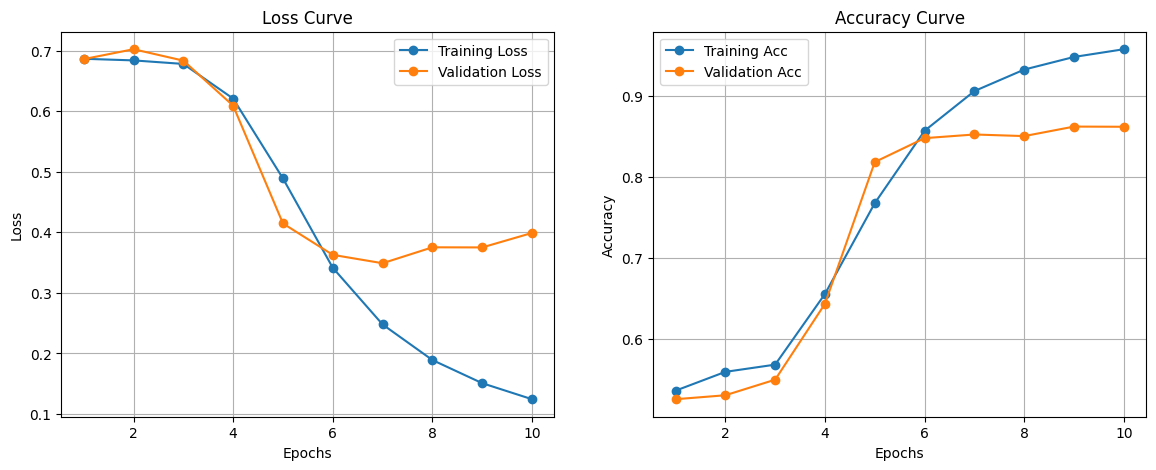

In [7]:
import time
import matplotlib.pyplot as plt


def binary_accuracy(preds, y):
    """
    Returns accuracy per batch, i.e. if you get 8/10 right, this returns 0.8
    """
    # Round predictions to the closest integer (0 or 1)
    rounded_preds = torch.round(preds)
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc


def train(model, loader, optimizer, criterion):
    # 1. Set the model to "Training Mode"
    # This turns ON Dropout (random noise) for regularization
    model.train()

    epoch_loss = 0
    epoch_acc = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # 2. Zero Gradients (Reset previous calculations)
        optimizer.zero_grad()

        # 3. Forward Pass
        # We pass the batch into the model object directly
        # .squeeze(1) removes the extra dimension: [64, 1] -> [64]
        predictions = model(batch_x).squeeze(1)

        # 4. Calculate Loss & Accuracy
        loss = criterion(predictions, batch_y)
        acc = binary_accuracy(predictions, batch_y)

        # 5. Backward Pass (Calculate Gradients)
        loss.backward()

        # 6. Optimization Step (Update Weights)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)


def evaluate(model, loader, criterion):
    # 1. Set the model to "Evaluation Mode"
    # This turns OFF Dropout so we get stable predictions
    model.eval()

    epoch_loss = 0
    epoch_acc = 0

    # 2. Disable Gradient Calculation
    # We don't need to update weights here
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x).squeeze(1)

            loss = criterion(predictions, batch_y)
            acc = binary_accuracy(predictions, batch_y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)


# --- Configuration ---
N_EPOCHS = 20
PATIENCE = 3
best_val_loss = float("inf")
patience_counter = 0

# History storage
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Starting training with Early Stopping (Patience={PATIENCE})...")

for epoch in range(N_EPOCHS):
    start_time = time.time()

    # 1. Train & Evaluate
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(valid_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(valid_acc)

    # 2. Early Stopping
    if valid_loss < best_val_loss:
        # A. IMPROVEMENT FOUND
        best_val_loss = valid_loss
        patience_counter = 0  # Reset the counter

        # Save the best model to disk
        torch.save(model.state_dict(), "best_sentiment_model.pth")
        print(f"Epoch {epoch+1:02}: New Best Val Loss: {valid_loss:.3f} (Saved)")

    else:
        # B. NO IMPROVEMENT
        patience_counter += 1
        print(
            f"Epoch {epoch+1:02}: No improvement. Patience {patience_counter}/{PATIENCE}"
        )

    end_time = time.time()
    mins, secs = divmod(end_time - start_time, 60)

    # Print stats
    print(f"Epoch {epoch+1:02} | Time: {int(mins)}m {int(secs)}s")
    print(f"\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%")
    print(f"\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%")

    # 3. Check Trigger
    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping triggered! Stopping at Epoch {epoch+1}")
        break

# --- Load the Best Version ---
print("\nLoading the best model weights...")
model.load_state_dict(torch.load("best_sentiment_model.pth"))
print("Model restored to best state.")

# --- Plotting the Curves ---
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Training Loss", marker="o")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss", marker="o")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Training Acc", marker="o")
plt.plot(epochs_range, history["val_acc"], label="Validation Acc", marker="o")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Testing the model

In [8]:
def predict_sentiment(sentence):
    # 1. Set model to evaluation mode
    model.eval()

    # 2. Clean and Tokenize (reusing the function from Step 2)
    # This turns "I love this!" into [10, 439, 11...]
    indices = clean_and_tokenize(sentence)

    # 3. Handle Length (Pad or Truncate to 400)
    if len(indices) < MAX_LEN:
        indices += [0] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN]

    # 4. Convert to Tensor & Add Batch Dimension
    # Shape becomes [1, 400] because the model expects a batch
    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    # 5. Predict
    prediction = model(tensor)
    score = prediction.item()

    # 6. Print Result
    status = "POSITIVE" if score > 0.5 else "NEGATIVE"
    print(f"Review: '{sentence}'")
    print(f"Score:  {score:.4f} ({status})\n")


for file_name in [
    "./aclImdb/test/pos/0_10.txt",
    "./aclImdb/test/pos/1_10.txt",
    "./aclImdb/test/neg/0_2.txt",
    "./aclImdb/test/neg/1_3.txt",
]:
    with open(file_name, "r", encoding="utf-8") as f:
        review_text = f.read()
        predict_sentiment(review_text)

Review: 'I went and saw this movie last night after being coaxed to by a few friends of mine. I'll admit that I was reluctant to see it because from what I knew of Ashton Kutcher he was only able to do comedy. I was wrong. Kutcher played the character of Jake Fischer very well, and Kevin Costner played Ben Randall with such professionalism. The sign of a good movie is that it can toy with our emotions. This one did exactly that. The entire theater (which was sold out) was overcome by laughter during the first half of the movie, and were moved to tears during the second half. While exiting the theater I not only saw many women in tears, but many full grown men as well, trying desperately not to let anyone see them crying. This movie was great, and I suggest that you go see it before you judge.'
Score:  0.9786 (POSITIVE)

Review: 'My boyfriend and I went to watch The Guardian.At first I didn't want to watch it, but I loved the movie- It was definitely the best movie I have seen in someti

## Step 7: Saving the model

In [9]:
# 1. Define the bundle
checkpoint = {
    "state_dict": model.state_dict(),
    "vocab": word_to_idx,
    "config": {
        "vocab_size": VOCAB_SIZE,
        "embed_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "output_dim": OUTPUT_DIM,
        "n_layers": N_LAYERS,
        "dropout": DROPOUT,
    },
}

# 2. Save it
print("Saving complete model bundle...")
torch.save(checkpoint, "sentiment_classifier_complete.pth")
print("Saved to 'sentiment_classifier_complete.pth'")

Saving complete model bundle...
Saved to 'sentiment_classifier_complete.pth'


In [10]:
# --- SIMULATING A FRESH START ---

def load_and_predict(text, model_path):
    # 1. Load the file
    print(f"Loading {model_path}...")
    checkpoint = torch.load(model_path, map_location=device)

    # 2. Extract Data
    vocab = checkpoint["vocab"]
    config = checkpoint["config"]
    state_dict = checkpoint["state_dict"]

    # 3. Rebuild the Model Structure
    # We use the 'config' dict to ensure the dimensions match exactly
    loaded_model = SentimentLSTM(
        vocab_size=config["vocab_size"],
        embed_dim=config["embed_dim"],
        hidden_dim=config["hidden_dim"],
        output_dim=config["output_dim"],
        n_layers=config["n_layers"],
        dropout=config["dropout"],
    )

    # 4. Load the Weights
    loaded_model.load_state_dict(state_dict)
    loaded_model.to(device)
    loaded_model.eval()

    # 5. Preprocessing (Internal Function)
    # We must recreate the tokenization logic using the LOADED vocab
    # (Simplified version of clean_and_tokenize)
    import re

    text = text.lower()
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    tokens = text.split()

    # Convert to indices
    indices = [vocab.get(t, vocab.get("<unk>", 0)) for t in tokens]

    # Pad/Truncate to 400
    if len(indices) < 400:
        indices += [0] * (400 - len(indices))
    else:
        indices = indices[:400]

    # 6. Predict
    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    prediction = loaded_model(tensor).item()

    status = "POSITIVE" if prediction > 0.5 else "NEGATIVE"
    print(f"Input: '{text}'")
    print(f"Prediction: {prediction:.4f} ({status})\n")


# --- Test the Reloaded Model ---
load_and_predict(
    "This is the best movie I have seen in years.", "sentiment_classifier_complete.pth"
)
load_and_predict(
    "Don't waste your time, it is garbage.", "sentiment_classifier_complete.pth"
)

Loading sentiment_classifier_complete.pth...
Input: 'this is the best movie i have seen in years'
Prediction: 0.9888 (POSITIVE)

Loading sentiment_classifier_complete.pth...
Input: 'dont waste your time it is garbage'
Prediction: 0.0360 (NEGATIVE)



## Step 8: Evaluating

Generating predictions for the test set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.90      0.80      0.84     12500
    Positive       0.82      0.91      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



<Figure size 800x600 with 0 Axes>

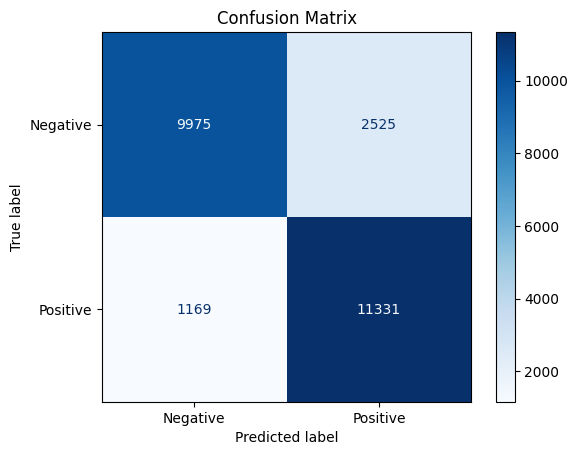

In [11]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate_metrics(model, loader):
    model.eval()

    # Store all results here
    y_true = []
    y_pred_probs = []

    print("Generating predictions for the test set...")

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)

            # Get probabilities
            predictions = model(batch_x).squeeze(1)

            # Move to CPU and convert to numpy for Scikit-Learn
            y_pred_probs.extend(predictions.cpu().numpy())
            y_true.extend(batch_y.cpu().numpy())

    # Convert probabilities to binary class labels (0 or 1)
    # Threshold is 0.5: > 0.5 is Positive, < 0.5 is Negative
    y_pred_labels = [1 if p > 0.5 else 0 for p in y_pred_probs]

    # --- 1. Text Report (Precision, Recall, F1) ---
    print("\n" + "=" * 50)
    print("CLASSIFICATION REPORT")
    print("=" * 50)
    print(
        classification_report(
            y_true, y_pred_labels, target_names=["Negative", "Positive"]
        )
    )

    # --- 2. Confusion Matrix Plot ---
    cm = confusion_matrix(y_true, y_pred_labels)

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.show()


# Run the evaluation
evaluate_metrics(model, test_loader)

# Part B: Named Entity Recognition

Install if necessary

In [12]:
# !pip install datasets pytorch-crf seqeval

## Step 1: Load and Inspect CoNLL-2003

In [13]:
import torch
from datasets import load_dataset
from collections import Counter
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# Load Data
print("Downloading CoNLL-2003...")
dataset = load_dataset("conll2003", revision="refs/convert/parquet")

d:\MSE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Inspect the Data Structure
train_data = dataset['train']
validation_data = dataset['validation']
test_data = dataset['test']

print(f"\nTraining Size: {len(train_data)}")
print(f"Validation Size: {len(validation_data)}")
print(f"Test Size:       {len(test_data)}")


Training Size: 14041
Validation Size: 3250
Test Size:       3453


In [15]:
# Inspect one sample
sample = train_data[0]
print("\n--- Sample 0 ---")
print(f"Tokens: {sample['tokens']}")
print(f"NER IDs: {sample['ner_tags']}")


--- Sample 0 ---
Tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
NER IDs: [3, 0, 7, 0, 0, 0, 7, 0, 0]


In [16]:
# Decode the Tags (Map IDs back to BIO labels)
label_list = train_data.features[f'ner_tags'].feature.names
print("\n--- Tag Mapping ---")
for i, label in enumerate(label_list):
    print(f"{i}: {label}")

# Visual check of the sample with tags
print("\n--- Annotated Sample ---")
for token, label_id in zip(sample['tokens'], sample['ner_tags']):
    print(f"{token:<15} -> {label_list[label_id]}")


--- Tag Mapping ---
0: O
1: B-PER
2: I-PER
3: B-ORG
4: I-ORG
5: B-LOC
6: I-LOC
7: B-MISC
8: I-MISC

--- Annotated Sample ---
EU              -> B-ORG
rejects         -> O
German          -> B-MISC
call            -> O
to              -> O
boycott         -> O
British         -> B-MISC
lamb            -> O
.               -> O


## Step 2: Preprocessing

In [17]:
# Build Vocabulary
def build_vocab(dataset, min_freq=2):
    counter = Counter()
    for item in dataset:
        counter.update(item["tokens"])

    # Start with special tokens
    vocab = {"<pad>": 0, "<unk>": 1}

    # Add words that appear at least min_freq times
    for word, count in counter.items():
        if count >= min_freq:
            vocab[word] = len(vocab)

    print(f"Vocabulary size: {len(vocab)}")
    return vocab


word_to_idx = build_vocab(train_data)


# Batching (Collate)
def collate_batch(batch):
    batch_input_ids = []
    batch_labels = []

    for item in batch:
        # Convert tokens to indices
        input_ids = [word_to_idx.get(w, word_to_idx["<unk>"]) for w in item["tokens"]]
        batch_input_ids.append(torch.tensor(input_ids, dtype=torch.long))

        # Labels are already IDs, just convert to tensor
        batch_labels.append(torch.tensor(item["ner_tags"], dtype=torch.long))

    # Pad sequences
    # padding_value=0 matches our '<pad>' index
    # For labels, we usually pad with -1 (ignore index) or 'O' tag.
    # Since we use CRF, we'll pad with 0 (which is 'O' in CoNLL) but handle masking later.
    padded_inputs = pad_sequence(batch_input_ids, batch_first=True, padding_value=0)
    padded_labels = pad_sequence(
        batch_labels, batch_first=True, padding_value=0
    )  # 0 is 'O' tag

    # Create mask (True where data exists, False where padding is)
    mask = padded_inputs != 0

    return padded_inputs, padded_labels, mask


# Create Loaders 
BATCH_SIZE = 32

train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
val_loader = DataLoader(
    validation_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)
test_loader = DataLoader(
    test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)

# Verify a batch
x, y, mask = next(iter(train_loader))
print(f"\nBatch Shapes:")
print(f"Input: {x.shape}")  # [Batch, Max_Seq_Len]
print(f"Labels: {y.shape}")  # [Batch, Max_Seq_Len]
print(f"Mask: {mask.shape}")  # [Batch, Max_Seq_Len]

Vocabulary size: 11984

Batch Shapes:
Input: torch.Size([32, 44])
Labels: torch.Size([32, 44])
Mask: torch.Size([32, 44])


In [18]:
# Tag Mappings exist 
tags = dataset['train'].features['ner_tags'].feature.names

# Create the mappings
tag_to_idx = {tag: i for i, tag in enumerate(tags)}
idx_to_tag = {i: tag for i, tag in enumerate(tags)}

print(f"Tag to Index: {tag_to_idx}")
print(f"Index to Tag: {idx_to_tag}")
print(f"Number of Tags: {len(tag_to_idx)}")

Tag to Index: {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}
Index to Tag: {0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-MISC', 8: 'I-MISC'}
Number of Tags: 9


## Step 3: BiLSTM-CRF Model

In [19]:
import torch.nn as nn
from torchcrf import CRF


class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags):
        super(BiLSTM_CRF, self).__init__()

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. BiLSTM Layer
        # hidden_dim // 2 because Bidirectional adds two halves together
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim // 2,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        # 3. Linear Layer (Projects LSTM features to Tag Space)
        self.hidden2tag = nn.Linear(hidden_dim, num_tags)

        # 4. CRF Layer
        self.crf = CRF(num_tags, batch_first=True)

    def get_emissions(self, inputs):
        # 1. Embed: Convert IDs to vectors
        embeds = self.embedding(inputs)

        # 2. BiLSTM: Get context from Left and Right
        lstm_out, _ = self.lstm(embeds)

        # 3. Linear: Turn context into raw Tag Scores (Emissions)
        emissions = self.hidden2tag(lstm_out)
        return emissions

    def forward(self, inputs, mask):
        # PREDICTION MODE
        emissions = self.get_emissions(inputs)
        # Ask CRF: "Given these raw scores, what is the most likely valid sequence of tags?"
        return self.crf.decode(emissions, mask=mask)

    def loss(self, inputs, tags, mask):
        # TRAINING MODE
        emissions = self.get_emissions(inputs)
        # Ask CRF: "How 'correct' was the actual true sequence compared to all other possibilities?"
        # minimize the negative likelihood (make the true path more likely)
        log_likelihood = self.crf(emissions, tags, mask=mask)
        return -log_likelihood


# --- Instantiate the Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get tag count
NUM_TAGS = len(tag_to_idx)
VOCAB_SIZE = len(word_to_idx)
EMBED_DIM = 100
HIDDEN_DIM = 256

model = BiLSTM_CRF(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_TAGS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Model created on {device}")
print(f"Tags: {NUM_TAGS} | Vocab: {VOCAB_SIZE}")

Model created on cuda
Tags: 9 | Vocab: 11984


In [20]:
# Training Loop with Gradient Clipping
import time
import torch.nn.utils as utils


def train(model, loader, optimizer):
    model.train()
    total_loss = 0

    for batch_x, batch_y, batch_mask in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_mask = batch_mask.to(device)

        optimizer.zero_grad()

        loss = model.loss(batch_x, batch_y, batch_mask)
        loss.backward()

        # Add Gradient Clipping
        # This prevents the model from taking massive, destructive steps
        utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


# Run Training
for epoch in range(5):
    start_time = time.time()
    loss = train(model, train_loader, optimizer)
    duration = time.time() - start_time

    print(f"Epoch {epoch+1}: Loss = {loss:.4f} | Time: {int(duration)}s")

Epoch 1: Loss = 237.1379 | Time: 18s
Epoch 2: Loss = 98.6093 | Time: 18s
Epoch 3: Loss = 53.9602 | Time: 17s
Epoch 4: Loss = 31.6380 | Time: 18s
Epoch 5: Loss = 18.6355 | Time: 18s


## Step 4: Evaluation and Analysis

Running evaluation on test set...

ENTITY-LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

         LOC       0.84      0.74      0.79      1668
        MISC       0.70      0.61      0.65       702
         ORG       0.76      0.60      0.67      1661
         PER       0.74      0.62      0.68      1617

   micro avg       0.77      0.65      0.71      5648
   macro avg       0.76      0.64      0.70      5648
weighted avg       0.77      0.65      0.71      5648

Overall Entity F1 Score: 0.7064

TOKEN-LEVEL CONFUSION MATRIX


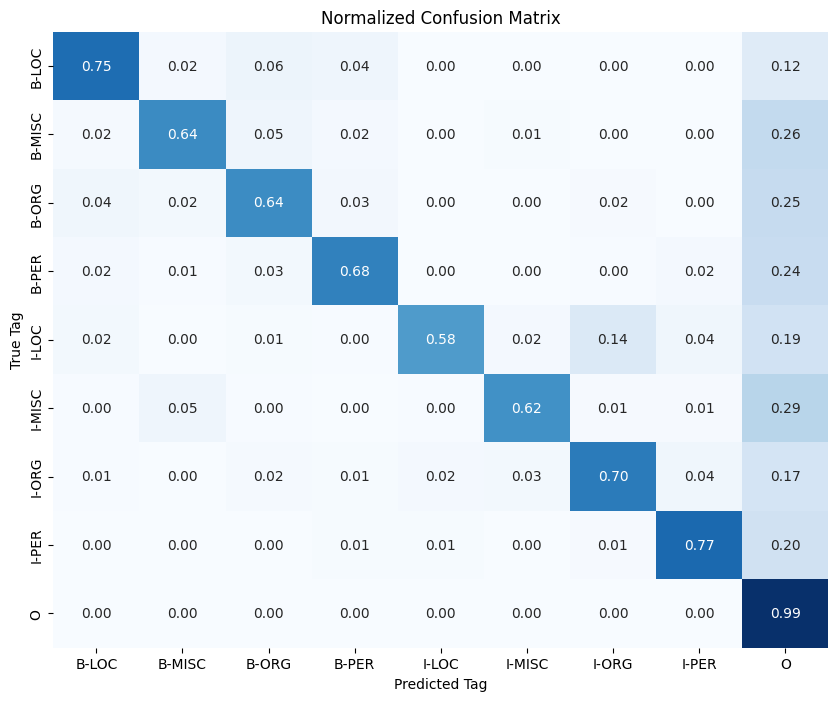

In [21]:
from seqeval.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def evaluate_and_plot(model, loader):
    model.eval()

    # Storage for SeqEval (Nested lists of Tags)
    seq_true_tags = []
    seq_pred_tags = []

    # Storage for Confusion Matrix (Flat lists of Tags)
    flat_true_tags = []
    flat_pred_tags = []

    print("Running evaluation on test set...")
    with torch.no_grad():
        for batch_x, batch_y, batch_mask in loader:
            batch_x = batch_x.to(device)
            batch_mask = batch_mask.to(device)

            # 1. Get Predictions
            batch_preds_ids = model(batch_x, batch_mask)

            # 2. Process Batch
            for i, preds_ids in enumerate(batch_preds_ids):
                # Length of the valid sentence (ignoring padding)
                length = len(preds_ids)

                # Get True IDs (truncated to length)
                true_ids = batch_y[i][:length].cpu().tolist()

                # Convert IDs -> Tag Strings
                pred_tags = [idx_to_tag[p] for p in preds_ids]
                true_tags = [idx_to_tag[t] for t in true_ids]

                # Append for SeqEval (Sequence Level)
                seq_pred_tags.append(pred_tags)
                seq_true_tags.append(true_tags)

                # Extend for Matrix (Token Level)
                flat_pred_tags.extend(pred_tags)
                flat_true_tags.extend(true_tags)

    # --- PART 1: TEXT REPORT (Entity Level) ---
    print("\n" + "=" * 50)
    print("ENTITY-LEVEL CLASSIFICATION REPORT")
    print("=" * 50)
    print(classification_report(seq_true_tags, seq_pred_tags))
    print(f"Overall Entity F1 Score: {f1_score(seq_true_tags, seq_pred_tags):.4f}")

    # --- PART 2: VISUAL REPORT (Token Level) ---
    print("\n" + "=" * 50)
    print("TOKEN-LEVEL CONFUSION MATRIX")
    print("=" * 50)

    # Get unique labels sorted to ensure consistent order
    unique_labels = sorted(list(set(flat_true_tags + flat_pred_tags)))

    # Calculate Matrix
    cm = confusion_matrix(flat_true_tags, flat_pred_tags, labels=unique_labels)

    # Normalize (Recall view: what % of True X was predicted as Y?)
    # Add epsilon to avoid division by zero
    cm_norm = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        xticklabels=unique_labels,
        yticklabels=unique_labels,
        cmap="Blues",
        cbar=False,
    )
    plt.xlabel("Predicted Tag")
    plt.ylabel("True Tag")
    plt.title("Normalized Confusion Matrix")
    plt.show()


# Run the unified function
evaluate_and_plot(model, test_loader)

# Part C: Siamese Network for Question Similarity

## Step 1: Load and Preprocess Data

In [5]:
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import torch.nn as nn

# 1. Load Data (Using GLUE's version of Quora Question Pairs)
print("Downloading Quora Question Pairs (GLUE/QQP)...")
dataset = load_dataset('glue', 'qqp')

train_data = dataset['train']
valid_data = dataset['validation']

print(f"\nTraining Samples: {len(train_data)}")
print(f"Validation Samples: {len(valid_data)}")

# 2. Inspect a Sample
sample = train_data[3]
print("\n--- Sample ---")
print(f"Q1: {sample['question1']}")
print(f"Q2: {sample['question2']}")
print(f"Label: {sample['label']} (1=Duplicate, 0=Different)")

# 3. Build Vocabulary (Simple white-space tokenizer)
# We need to look at both Q1 and Q2 to build the vocab
def build_vocab(dataset, min_freq=2):
    counter = Counter()
    for item in dataset:
        counter.update(item['question1'].lower().split())
        counter.update(item['question2'].lower().split())
        
    vocab = {'<pad>': 0, '<unk>': 1}
    for word, count in counter.items():
        if count >= min_freq:
            vocab[word] = len(vocab)
            
    return vocab

# # We'll use a subset for speed if you are on CPU
# # If you have a GPU, you can use the full set.
# # Let's take 20,000 samples for training to keep it fast for learning.
# SUBSET_SIZE = 20000
# train_data = train_data.select(range(SUBSET_SIZE))
# valid_data = valid_data.select(range(2000)) # 2000 validation

print("\nBuilding Vocabulary (this might take a moment)...")
word_to_idx = build_vocab(train_data)
print(f"Vocabulary Size: {len(word_to_idx)}")

# 4. Collate Function (Batching Pairs)
def collate_batch(batch):
    q1_list, q2_list, labels = [], [], []
    
    for item in batch:
        # Process Q1
        q1_tokens = [word_to_idx.get(w, word_to_idx['<unk>']) for w in item['question1'].lower().split()]
        q1_list.append(torch.tensor(q1_tokens, dtype=torch.long))
        
        # Process Q2
        q2_tokens = [word_to_idx.get(w, word_to_idx['<unk>']) for w in item['question2'].lower().split()]
        q2_list.append(torch.tensor(q2_tokens, dtype=torch.long))
        
        labels.append(torch.tensor(item['label'], dtype=torch.float))
        
    # Pad sequences
    q1_padded = pad_sequence(q1_list, batch_first=True, padding_value=0)
    q2_padded = pad_sequence(q2_list, batch_first=True, padding_value=0)
    labels_tensor = torch.stack(labels)
    
    return q1_padded, q2_padded, labels_tensor

# Create Loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_batch)
valid_loader = DataLoader(valid_data, batch_size=64, shuffle=False, collate_fn=collate_batch)

# Check one batch
q1, q2, y = next(iter(train_loader))
print(f"\nBatch Shapes:")
print(f"Q1: {q1.shape}")
print(f"Q2: {q2.shape}")
print(f"Labels: {y.shape}")


Training Samples: 363846
Validation Samples: 40430

--- Sample ---
Q1: What can one do after MBBS?
Q2: What do i do after my MBBS ?
Label: 1 (1=Duplicate, 0=Different)

Building Vocabulary (this might take a moment)...
Vocabulary Size: 94217

Batch Shapes:
Q1: torch.Size([64, 33])
Q2: torch.Size([64, 52])
Labels: torch.Size([64])


## Step 2: Define the Model

In [ ]:
class SiameseLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SiameseLSTM, self).__init__()

        # 1. Embedding Layer (Shared)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. LSTM Encoder (Shared)
        # We use a simple uni-directional LSTM
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # 3. Classifier Layer
        # It takes the difference vector (size hidden_dim) and outputs 1 score
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward_one(self, x):
        # Helper to process one question
        embeds = self.embedding(x)

        # LSTM returns: output, (hidden_state, cell_state)
        # We want the LAST hidden state to represent the whole sentence
        _, (hidden, _) = self.lstm(embeds)

        # 'hidden' shape: [1, batch_size, hidden_dim] -> squeeze to [batch_size, hidden_dim]
        return hidden[-1]

    def forward(self, q1, q2):
        # 1. Encode Q1 ("Left Twin")
        u = self.forward_one(q1)

        # 2. Encode Q2 ("Right Twin")
        # we call the EXACT SAME function/layers for shared weights
        v = self.forward_one(q2)

        # 3. Combine
        # We use Absolute Difference: |u - v| (manhattan distance)
        # If u and v are identical, this is 0.
        diff = torch.abs(u - v)

        # 4. Classify
        logits = self.classifier(diff)

        # Return probability (Sigmoid)
        return torch.sigmoid(logits).squeeze()


# --- Instantiate ---
VOCAB_SIZE = len(word_to_idx)
EMBED_DIM = 100
HIDDEN_DIM = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss()  # Binary Cross Entropy

print(f"Siamese Model initialized on {device}")

Siamese Model initialized on cuda


## Step 3: Training

In [7]:
import time
from sklearn.metrics import accuracy_score


def train_siamese_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for q1, q2, labels in loader:
        q1, q2, labels = q1.to(device), q2.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        probs = model(q1, q2)

        # Calculate Loss
        loss = criterion(probs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Store for metrics
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


# --- Run Training ---
print("Starting Siamese Training...")

for epoch in range(5):
    start = time.time()
    train_loss, train_acc = train_siamese_epoch(model, train_loader, optimizer)
    duration = time.time() - start

    print(
        f"Epoch {epoch+1}: Loss = {train_loss:.4f} | Acc = {train_acc:.4f} | Time: {int(duration)}s"
    )

Starting Siamese Training...
Epoch 1: Loss = 0.5330 | Acc = 0.7219 | Time: 38s
Epoch 2: Loss = 0.4275 | Acc = 0.8034 | Time: 37s
Epoch 3: Loss = 0.3702 | Acc = 0.8366 | Time: 36s
Epoch 4: Loss = 0.3225 | Acc = 0.8614 | Time: 38s
Epoch 5: Loss = 0.2827 | Acc = 0.8816 | Time: 40s


## Step 4: Validation

In [9]:
def evaluate_siamese(model, loader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for q1, q2, labels in loader:
            q1, q2, labels = q1.to(device), q2.to(device), labels.to(device)
            
            # Forward pass
            probs = model(q1, q2)
            loss = criterion(probs, labels)
            
            total_loss += loss.item()
            
            # Convert Probability -> 0 or 1
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    
    print("--- Validation Results ---")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    
    return acc

val_acc = evaluate_siamese(model, valid_loader)

--- Validation Results ---
Loss: 0.3900
Accuracy: 0.8297


In [10]:
def check_similarity(q1_text, q2_text):
    model.eval()

    # 1. Tokenize & Encode
    def encode(text):
        tokens = [
            word_to_idx.get(w, word_to_idx["<unk>"]) for w in text.lower().split()
        ]
        return (
            torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
        )  # Shape [1, seq_len]

    t1 = encode(q1_text)
    t2 = encode(q2_text)

    # 2. Predict
    with torch.no_grad():
        similarity_score = model(t1, t2).item()

    # 3. Output
    print(f"\nQ1: {q1_text}")
    print(f"Q2: {q2_text}")
    print(f"Similarity Score: {similarity_score:.4f}")

    if similarity_score > 0.5:
        print(">> DUPLICATE")
    else:
        print(">> DIFFERENT")


# --- Try these pairs ---

# Case 1: Obvious Duplicate
check_similarity(
    "How can I learn Python?", "What is the best way to start learning Python?"
)

# Case 2: Different Topic
check_similarity("How can I learn Python?", "How do I cook a steak?")

# Case 3: Tricky (Same words, different meaning)
check_similarity("Do you like Apple?", "Do you like apples?")


Q1: How can I learn Python?
Q2: What is the best way to start learning Python?
Similarity Score: 0.6993
>> DUPLICATE

Q1: How can I learn Python?
Q2: How do I cook a steak?
Similarity Score: 0.0974
>> DIFFERENT

Q1: Do you like Apple?
Q2: Do you like apples?
Similarity Score: 0.0785
>> DIFFERENT


In [ ]:
import torch.nn.functional as F


def get_cosine_similarity(q1_text, q2_text):
    model.eval()

    # Helper to get the vector representation (before the classifier)
    def get_vector(text):
        tokens = [
            word_to_idx.get(w, word_to_idx["<unk>"]) for w in text.lower().split()
        ]
        tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            # Use the 'forward_one' method we defined earlier
            # This returns the LSTM output vector (size 128)
            vector = model.forward_one(tensor)
        return vector

    v1 = get_vector(q1_text)
    v2 = get_vector(q2_text)

    # Cosine Similarity 
    # Cosine = (A . B) / (|A| * |B|)
    cosine_sim = F.cosine_similarity(v1, v2).item()

    print(f"\n--- Internal Representation ---")
    print(f"Cosine Similarity of LSTM Vectors: {cosine_sim:.4f}")
    return cosine_sim


# Compare the classifier score vs raw vector similarity
q_a = "Where is the capital of France?"
q_b = "What represents the capital of France?"

check_similarity(q_a, q_b)
get_cosine_similarity(q_a, q_b)


Q1: Where is the capital of France?
Q2: What represents the capital of France?
Similarity Score: 0.7943
>> DUPLICATE

--- Internal Representation ---
Cosine Similarity of LSTM Vectors: 0.9699


0.9699169397354126

## Step 5: Calculate AUC-ROC and Plot Curve

Calculating ROC metrics...

AUC-ROC Score: 0.9023


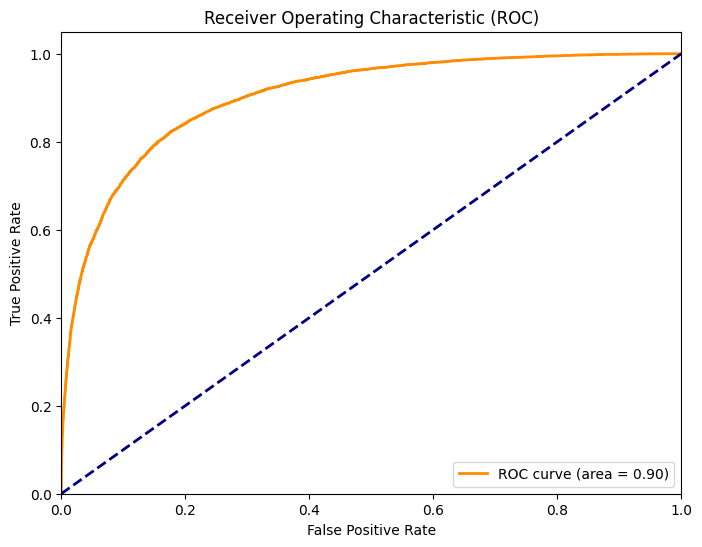

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


def plot_roc_curve(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    print("Calculating ROC metrics...")

    with torch.no_grad():
        for q1, q2, labels in loader:
            q1, q2, labels = q1.to(device), q2.to(device), labels.to(device)

            # Get raw probabilities (0.0 to 1.0)
            probs = model(q1, q2)

            all_probs.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    # Calculate ROC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    print(f"\nAUC-ROC Score: {roc_auc:.4f}")

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})"
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC)")
    plt.legend(loc="lower right")
    plt.show()


plot_roc_curve(model, valid_loader)